# 비용이 다른 미로: 사전학습 → SFT → PPO

벽으로 막힌 미로에서 목표로 이동합니다. 일반 바닥은 비용 1, 늪은 비용 4입니다.
사전학습은 다음 위치와 비용, SFT는 가장 짧은 경로, PPO는 도착과 총비용을 학습합니다.
각 단계의 실행 화면에서 모델을 확인한 뒤 다음 단계로 넘어가세요.

[규칙과 학습 구조](https://github.com/HisameOgasahara/tmp_full_Training/blob/main/docs/학습설계.md)

## 0. 준비

Colab 런타임을 T4 GPU로 설정하세요.

In [1]:
import importlib
import io
import os
from pathlib import Path
import shutil
import subprocess
import sys
import tarfile
import tempfile
import urllib.request

REPO_URL = "https://github.com/HisameOgasahara/tmp_full_Training.git"
REPO_ROOT = Path(tempfile.mkdtemp(prefix="weighted_maze_")) / "repository"
subprocess.run(["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(REPO_ROOT)], check=True)
REVISION = subprocess.check_output(["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"], text=True).strip()

uv_executable = shutil.which("uv")
if uv_executable is None:
    if not sys.platform.startswith("linux"):
        raise RuntimeError("로컬에서는 uv를 설치한 뒤 이 셀을 실행하세요. Colab에서는 자동 준비됩니다.")
    archive_url = "https://github.com/astral-sh/uv/releases/download/0.12.23/uv-x86_64-unknown-linux-gnu.tar.gz"
    data = urllib.request.urlopen(archive_url, timeout=120).read()
    with tarfile.open(fileobj=io.BytesIO(data), mode="r:gz") as archive:
        member = next(item for item in archive.getmembers() if item.name.endswith("/uv") and item.isfile())
        uv_path = REPO_ROOT.parent / "uv"
        uv_path.write_bytes(archive.extractfile(member).read())
    uv_path.chmod(0o755)
    uv_executable = str(uv_path)

import torch
subprocess.run([uv_executable, "pip", "install", "--system", "--python", sys.executable,
                "numpy>=1.26,<3", "matplotlib>=3.8,<4", "ipywidgets>=8.1,<9"], check=True)
subprocess.run([uv_executable, "pip", "install", "--system", "--python", sys.executable,
                "--no-deps", "--editable", str(REPO_ROOT)], check=True)
for name in list(sys.modules):
    if name == "maze_training" or name.startswith("maze_training."):
        del sys.modules[name]
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
importlib.invalidate_caches()
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass
print("실제 실행 커밋:", REVISION)
print("코드 위치:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("장치:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (t4 프로필은 GPU 권장)")

실제 실행 커밋: 685611f676e2991562f4df0bfda10bcb2b80dafb
코드 위치: /tmp/weighted_maze_an9sgl_z/repository
PyTorch: 2.11.0+cu130
장치: Tesla T4


### 설정

`t4`는 전체 학습, `smoke`는 짧은 실행입니다.
중단한 사전학습 또는 SFT를 이어갈 때 `RESUME = True`를 사용하고, 새 단계는 `False`로 설정하세요.
이번 환경의 저장 위치는 `weighted_maze_v2_runs`입니다.

In [2]:
PROFILE = "t4"
RESUME = False
CONFIG_PATH = str(REPO_ROOT / "configs" / f"{PROFILE}.json")
OUTPUT_ROOT = Path("/content/weighted_maze_v2_runs") if Path("/content").exists() else REPO_ROOT / "runs" / "weighted_maze"
OUTPUT_DIR = OUTPUT_ROOT / PROFILE
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from maze_training.training import run_stage
from maze_training.notebook import report_world, report_navigation, show_training_curve, launch_world, launch_navigation, report_actions
from maze_training.runtime import read_config, seed_runtime, create_model, choose_device, save_checkpoint, write_json

config = read_config(CONFIG_PATH)
model_for_size, _ = create_model(config, choose_device())
print("파라미터:", f"{sum(p.numel() for p in model_for_size.parameters()):,}")
print("저장 위치:", OUTPUT_DIR)
del model_for_size

파라미터: 809,286
저장 위치: /content/weighted_maze_v2_runs/t4


### 선택: Drive 저장

학습 전에 `USE_DRIVE = True`로 설정하면 Drive에 저장합니다.

In [3]:
USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_DIR = Path("/content/drive/MyDrive/weighted_maze_v2_training") / PROFILE
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("저장 위치:", OUTPUT_DIR)

저장 위치: /content/weighted_maze_v2_runs/t4


## 1. 사전학습 — 다음 위치와 이동 비용 예측

무작위 위치·행동의 실제 이동 기록을 학습합니다.
벽 충돌은 제자리, 일반 바닥과 늪은 서로 다른 비용으로 처리됩니다.

pretrain: 809,286 parameters | Tesla T4 | 0 → 1500 updates
[pretrain 1/1500] loss=4.3887 accuracy=0.0156 gradient_norm=inf elapsed=1.6s
[pretrain 50/1500] loss=3.7780 accuracy=0.0625 gradient_norm=1.6315 elapsed=2.4s
[pretrain 100/1500] loss=3.7850 accuracy=0.0312 gradient_norm=1.4750 elapsed=3.5s
[pretrain 150/1500] loss=3.6745 accuracy=0.0312 gradient_norm=1.4660 elapsed=4.7s
[pretrain 200/1500] loss=3.5520 accuracy=0.0156 gradient_norm=2.9032 elapsed=7.0s
[pretrain 250/1500] loss=3.3772 accuracy=0.0938 gradient_norm=1.8671 elapsed=8.9s
[pretrain 300/1500] loss=2.6843 accuracy=0.2188 gradient_norm=2.6493 elapsed=9.7s
[pretrain 350/1500] loss=2.3466 accuracy=0.2812 gradient_norm=2.5562 elapsed=10.4s
[pretrain 400/1500] loss=1.9140 accuracy=0.5000 gradient_norm=2.6502 elapsed=11.1s
[pretrain 450/1500] loss=1.3747 accuracy=0.6875 gradient_norm=4.0196 elapsed=11.9s
[pretrain 500/1500] loss=1.6019 accuracy=0.5781 gradient_norm=4.7243 elapsed=12.6s
[pretrain 550/1500] loss=1.1829 accuracy=

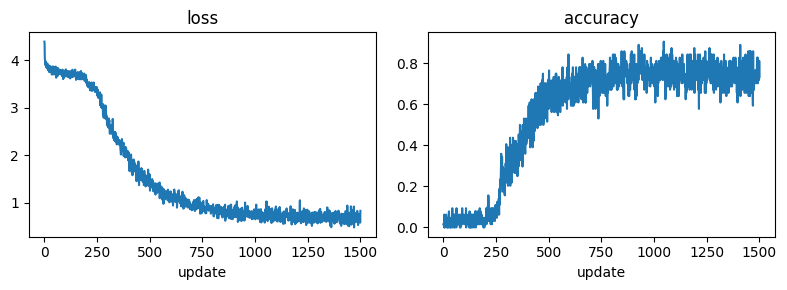

In [4]:
PRETRAIN_PATH = run_stage("pretrain", CONFIG_PATH, OUTPUT_DIR, resume=RESUME)
show_training_curve(OUTPUT_DIR, "pretrain")

### 1단계 평가와 직접 실행

다음 위치 정확도와 비용 오차를 확인하세요. 행동을 바꾸면 예측이 갱신됩니다.
실제 한 걸음을 실행해 예측 위치·비용과 환경 결과를 비교하세요.

In [5]:
PRETRAIN_PATH = str(OUTPUT_DIR / "pretrain.pt")
world_report = report_world(PRETRAIN_PATH)
world_demo = launch_world(PRETRAIN_PATH)

{
  "split": "validation",
  "samples": 512,
  "next_position_accuracy": 0.76171875,
  "cost_mae": 1.2812223434448242
}
next_position_accuracy는 높을수록, cost_mae는 낮을수록 좋습니다.


HTML(value='<p>파란 점: 현재 위치 · 흰색: 일반 바닥(비용 1) · 진회색: 벽 · 갈색 M: 늪(비용 4) · 초록색 G: 목표<br>도착 칸의 비용을 지불하고, 벽 충돌에는 추가…

HTML(value='<p>파란 점: 행동 전 위치 · 주황색 테두리: 실제 이동 후 위치</p>')

## 2. SFT — 벽을 피해 목표로 이동

BFS의 다음 행동을 모방합니다. BFS는 이동 횟수를 최소화합니다.
학습 지도는 BFS 경로보다 길지만 비용이 작은 우회로를 함께 갖습니다.

sft: 809,286 parameters | Tesla T4 | 0 → 4000 updates
[sft 1/4000] loss=0.7057 accuracy=0.5938 gradient_norm=4.6715 elapsed=0.9s
[sft 50/4000] loss=0.1894 accuracy=0.9375 gradient_norm=0.8879 elapsed=1.5s
[sft 100/4000] loss=0.1671 accuracy=0.9062 gradient_norm=1.5381 elapsed=2.7s
[sft 150/4000] loss=0.2467 accuracy=0.8906 gradient_norm=1.1663 elapsed=3.3s
[sft 200/4000] loss=0.2368 accuracy=0.9375 gradient_norm=0.7899 elapsed=4.4s
[sft 250/4000] loss=0.1973 accuracy=0.9531 gradient_norm=1.4324 elapsed=5.0s
[sft 300/4000] loss=0.1667 accuracy=0.9062 gradient_norm=1.4640 elapsed=6.2s
[sft 350/4000] loss=0.1991 accuracy=0.9062 gradient_norm=0.9829 elapsed=6.8s
[sft 400/4000] loss=0.2358 accuracy=0.9219 gradient_norm=0.7923 elapsed=7.9s
[sft 450/4000] loss=0.2757 accuracy=0.9062 gradient_norm=1.4992 elapsed=8.6s
[sft 500/4000] loss=0.1451 accuracy=0.9375 gradient_norm=0.6297 elapsed=9.7s
[sft 550/4000] loss=0.1484 accuracy=0.9219 gradient_norm=0.9350 elapsed=10.6s
[sft 600/4000] loss=0.15

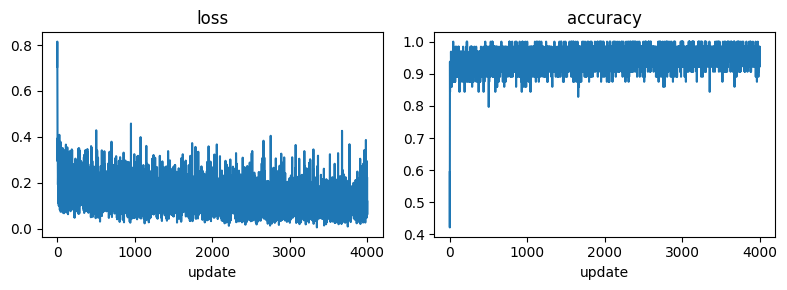

In [6]:
SFT_PATH = run_stage("sft", CONFIG_PATH, OUTPUT_DIR, resume=RESUME)
show_training_curve(OUTPUT_DIR, "sft")

### 2단계 평가와 직접 실행

BFS는 최단 경로, Dijkstra는 최소 비용 경로의 비교 기준입니다.
학습·검증 지도의 BFS 행동 정확도와 원래 출력의 벽 확률을 먼저 확인하세요.
이동 화면에서는 벽 방향을 제외합니다. 도착률·반복률·성공 시 비용을 비교하세요.

In [7]:
SFT_PATH = str(OUTPUT_DIR / "sft.pt")
sft_train_actions = report_actions(SFT_PATH, split="train")
sft_validation_actions = report_actions(SFT_PATH, split="validation")
sft_report = report_navigation({"SFT": SFT_PATH}, CONFIG_PATH)
sft_demo = launch_navigation({"SFT": SFT_PATH}, CONFIG_PATH)

{
  "split": "train",
  "states": 54186,
  "raw_bfs_action_accuracy": 0.7478684531059683,
  "masked_bfs_action_accuracy": 0.9653785110545159,
  "raw_wall_probability": 0.24232357478731362
}
{
  "split": "validation",
  "states": 660,
  "raw_bfs_action_accuracy": 0.7257575757575757,
  "masked_bfs_action_accuracy": 0.9621212121212122,
  "raw_wall_probability": 0.25608314400339044
}


HTML(value='<table><tr><th>정책</th><th>도착률</th><th>시간초과율</th><th>반복률</th><th>평균 보상</th><th>성공 시 비용</th><th>최소 비…

validation: 같은 미로 24개, 모델 행동은 argmax입니다.
반복률은 같은 위치를 재방문한 지도 비율입니다. 벽 방향은 학습·평가·실행에서 동일하게 제외합니다.


HTML(value='<p>파란 점: 현재 위치 · 흰색: 일반 바닥(비용 1) · 진회색: 벽 · 갈색 M: 늪(비용 4) · 초록색 G: 목표<br>도착 칸의 비용을 지불하고, 벽 충돌에는 추가…

### 선택: SFT 추가 학습

기본 길찾기를 더 학습하려면 `EXTEND_SFT = True`로 설정하세요.
`SFT_TOTAL_STEPS`는 기존 학습을 포함한 총 업데이트 수입니다.

In [8]:
EXTEND_SFT = False
SFT_TOTAL_STEPS = 6000 if PROFILE == "t4" else 8
if EXTEND_SFT:
    SFT_PATH = run_stage("sft", CONFIG_PATH, OUTPUT_DIR, steps=SFT_TOTAL_STEPS, resume=True)
    show_training_curve(OUTPUT_DIR, "sft")
    sft_report = report_navigation({"SFT": SFT_PATH}, CONFIG_PATH)

## 3. PPO — 도착을 유지하며 총비용 줄이기

현재 SFT에서 시작합니다. 가치 손실은 가치 출력만 학습하고 공통 Transformer는 바꾸지 않습니다.
첫 rollout으로 가치 출력을 먼저 학습하고, SFT 기준 KL로 행동 변화량을 제한합니다.
학습 보상에는 BFS 거리 potential을 더해 진행 신호를 제공합니다. 최종 평가는 원래 보상과 비용을 사용합니다.
아래 셀은 PPO를 새로 시작해 첫 50회 뒤 검증합니다. 이 셀을 다시 실행하면 실험을 다시 시작합니다.
이어 학습은 다음 **50회 더 학습** 셀을 사용하세요.

시작 SFT와 구간별 PPO 중 도착률이 가장 높은 모델을 선택하고, 동점이면 평균 보상으로 선택합니다.
선택 모델은 `ppo_refinement/selected_policy.pt`에 저장합니다.

HTML(value='<table><tr><th>정책</th><th>도착률</th><th>시간초과율</th><th>반복률</th><th>평균 보상</th><th>성공 시 비용</th><th>최소 비…

validation: 같은 미로 24개, 모델 행동은 argmax입니다.
반복률은 같은 위치를 재방문한 지도 비율입니다. 벽 방향은 학습·평가·실행에서 동일하게 제외합니다.
ppo: 809,286 parameters | Tesla T4 | 0 → 50 updates
[ppo 1/50] mean_return=2.7625 sampled_success_rate=1.0000 mean_cost=22.3750 transitions=190.0000 loss=1.1474 value_loss=2.3418 entropy=0.2763 approx_kl=0.0002 reference_kl=0.0002 early_stop=0.0000 elapsed=0.6s
[ppo 50/50] mean_return=0.8375 sampled_success_rate=0.9375 mean_cost=38.5000 transitions=298.0000 loss=0.7253 value_loss=1.4455 entropy=0.2586 approx_kl=0.0000 reference_kl=0.0102 early_stop=0.0000 elapsed=20.5s
저장 완료: /content/weighted_maze_v2_runs/t4/ppo_refinement/ppo.pt


HTML(value='<table><tr><th>정책</th><th>도착률</th><th>시간초과율</th><th>반복률</th><th>평균 보상</th><th>성공 시 비용</th><th>최소 비…

validation: 같은 미로 24개, 모델 행동은 argmax입니다.
반복률은 같은 위치를 재방문한 지도 비율입니다. 벽 방향은 학습·평가·실행에서 동일하게 제외합니다.
검증 선택: PPO 50회 | 도착률 79.2% | 평균 보상 0.121


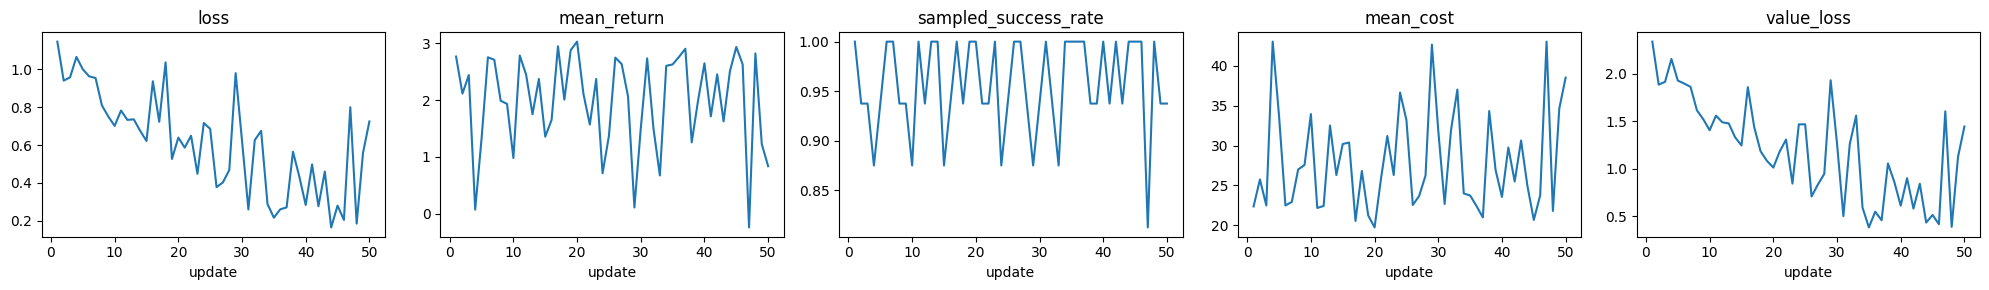

In [9]:
import json

SFT_PATH = str(OUTPUT_DIR / "sft.pt")
PPO_DIR = OUTPUT_DIR / "ppo_refinement"
PPO_DIR.mkdir(parents=True, exist_ok=True)
PPO_INTERVAL = 50 if PROFILE == "t4" else 1
PPO_LIMIT = config["ppo"]["steps"]
SELECTION_PATH = PPO_DIR / "selection.json"
SELECTED_PATH = PPO_DIR / "selected_policy.pt"
baseline_report = report_navigation({"SFT": SFT_PATH}, CONFIG_PATH)
shutil.copy2(SFT_PATH, PPO_DIR / "initial_sft.pt")
shutil.copy2(SFT_PATH, SELECTED_PATH)
write_json(SELECTION_PATH, {"source": "SFT", "step": 0, "metrics": baseline_report["policies"]["SFT"]})

def evaluate_and_save_ppo():
    candidate_path = PPO_DIR / "ppo.pt"
    payload = torch.load(candidate_path, map_location="cpu", weights_only=True)
    step = payload["step"]
    del payload
    report = report_navigation({"시작 SFT": str(PPO_DIR / "initial_sft.pt"), "PPO": str(candidate_path)}, CONFIG_PATH)
    metrics = report["policies"]["PPO"]
    shutil.copy2(candidate_path, PPO_DIR / f"ppo_{step:04d}.pt")
    write_json(PPO_DIR / f"validation_{step:04d}.json", report)
    selected = json.loads(SELECTION_PATH.read_text(encoding="utf-8"))
    score = lambda values: (values["success_rate"], values["mean_return"])
    if score(metrics) > score(selected["metrics"]):
        shutil.copy2(candidate_path, SELECTED_PATH)
        selected = {"source": "PPO", "step": step, "metrics": metrics}
        write_json(SELECTION_PATH, selected)
    print(f"검증 선택: {selected['source']} {selected['step']}회 | 도착률 {selected['metrics']['success_rate']:.1%} | 평균 보상 {selected['metrics']['mean_return']:.3f}")
    return report

PPO_PATH = run_stage("ppo", CONFIG_PATH, PPO_DIR, steps=min(PPO_INTERVAL, PPO_LIMIT), initialize_from=SFT_PATH)
comparison = evaluate_and_save_ppo()
show_training_curve(PPO_DIR, "ppo")

### 50회 더 학습

반복 실행하면 50회씩 총 250회까지 이어 학습·검증합니다.
`smoke`에서는 한 번에 1회씩 총 2회 실행합니다.

ppo: 809,286 parameters | Tesla T4 | 50 → 100 updates
[ppo 100/100] mean_return=2.8000 sampled_success_rate=1.0000 mean_cost=22.0000 transitions=172.0000 loss=0.2566 value_loss=0.4587 entropy=0.2196 approx_kl=0.0000 reference_kl=0.0318 early_stop=0.0000 elapsed=17.7s
저장 완료: /content/weighted_maze_v2_runs/t4/ppo_refinement/ppo.pt


HTML(value='<table><tr><th>정책</th><th>도착률</th><th>시간초과율</th><th>반복률</th><th>평균 보상</th><th>성공 시 비용</th><th>최소 비…

validation: 같은 미로 24개, 모델 행동은 argmax입니다.
반복률은 같은 위치를 재방문한 지도 비율입니다. 벽 방향은 학습·평가·실행에서 동일하게 제외합니다.
검증 선택: PPO 50회 | 도착률 79.2% | 평균 보상 0.121


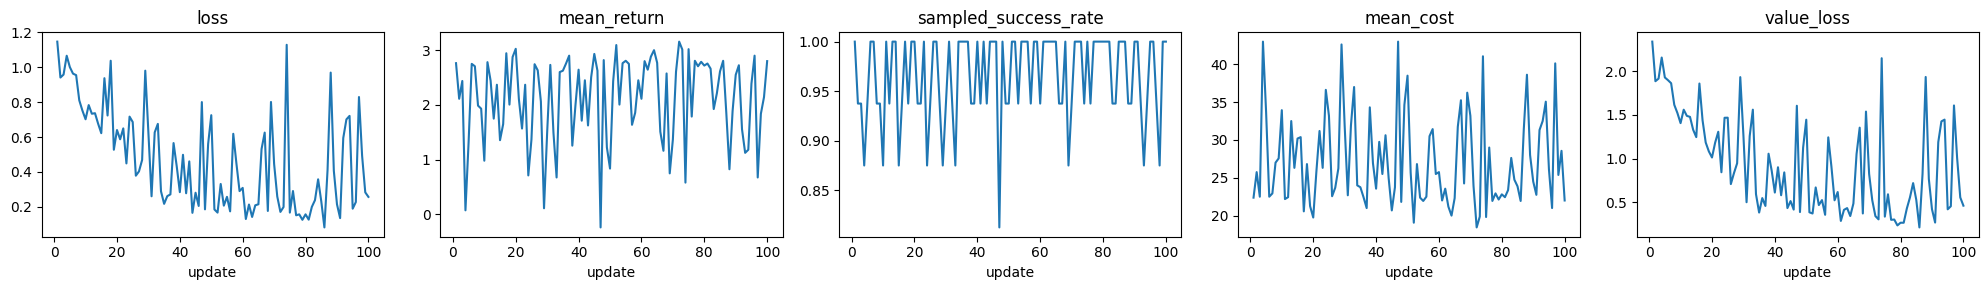

In [10]:
payload = torch.load(PPO_DIR / "ppo.pt", map_location="cpu", weights_only=True)
completed_steps = payload["step"]
del payload
next_steps = min(completed_steps + PPO_INTERVAL, PPO_LIMIT)
if next_steps > completed_steps:
    PPO_PATH = run_stage("ppo", CONFIG_PATH, PPO_DIR, steps=next_steps, resume=True)
    comparison = evaluate_and_save_ppo()
    show_training_curve(PPO_DIR, "ppo")
else:
    print(f"PPO {completed_steps}회 완료")

### 3단계 나란히 실행

시작 SFT와 선택 모델의 경로·총비용을 같은 지도에서 비교하세요.

In [11]:
selected = json.loads(SELECTION_PATH.read_text(encoding="utf-8"))
print("선택 모델:", selected["source"], "PPO 업데이트:", selected["step"])
comparison_demo = launch_navigation({"시작 SFT": str(PPO_DIR / "initial_sft.pt"), "검증 선택": str(SELECTED_PATH)}, CONFIG_PATH)

선택 모델: PPO PPO 업데이트: 50


HTML(value='<p>파란 점: 현재 위치 · 흰색: 일반 바닥(비용 1) · 진회색: 벽 · 갈색 M: 늪(비용 4) · 초록색 G: 목표<br>도착 칸의 비용을 지불하고, 벽 충돌에는 추가…

ValueError: expected non-negative integer

## 4. 최종 테스트

모델 선택을 마친 뒤 다른 지도에서 평가합니다.
도착률·평균 보상과 성공 시 비용·최소 비용 대비 초과 비용을 비교하세요.

In [12]:
final_test = report_navigation({
    "시작 SFT": str(PPO_DIR / "initial_sft.pt"),
    "마지막 PPO": str(PPO_DIR / "ppo.pt"),
    "검증 선택": str(SELECTED_PATH),
}, CONFIG_PATH, split="test")

HTML(value='<table><tr><th>정책</th><th>도착률</th><th>시간초과율</th><th>반복률</th><th>평균 보상</th><th>성공 시 비용</th><th>최소 비…

test: 같은 미로 48개, 모델 행동은 argmax입니다.
반복률은 같은 위치를 재방문한 지도 비율입니다. 벽 방향은 학습·평가·실행에서 동일하게 제외합니다.


## 5. 선택: 단계 생략 비교

스위치를 켠 실험만 실행합니다. 사전학습 생략은 무작위 초기화 → SFT → PPO,
SFT 생략은 사전학습 → PPO입니다. 후속 단계 업데이트 수를 맞춰 비교합니다.

In [ ]:
RUN_WITHOUT_PRETRAIN = False
if RUN_WITHOUT_PRETRAIN:
    ablation_dir = OUTPUT_DIR / "without_pretrain"
    seed_runtime(config["seed"])
    random_model, _ = create_model(config, choose_device())
    random_path = ablation_dir / "random_initialization.pt"
    save_checkpoint(random_path, random_model, config, "random_initialization", 0)
    del random_model
    sft_payload = torch.load(PPO_DIR / "initial_sft.pt", map_location="cpu", weights_only=True)
    sft_steps = sft_payload["step"]
    del sft_payload
    run_stage("sft", CONFIG_PATH, ablation_dir, steps=sft_steps, initialize_from=random_path)
    ppo_payload = torch.load(PPO_DIR / "ppo.pt", map_location="cpu", weights_only=True)
    ppo_steps = ppo_payload["step"]
    del ppo_payload
    run_stage("ppo", CONFIG_PATH, ablation_dir, steps=ppo_steps)
    report_navigation({"전체 흐름": str(PPO_DIR / "ppo.pt"), "사전학습 생략": str(ablation_dir / "ppo.pt")}, CONFIG_PATH)

In [ ]:
RUN_WITHOUT_SFT = False
if RUN_WITHOUT_SFT:
    ablation_dir = OUTPUT_DIR / "without_sft"
    ppo_payload = torch.load(PPO_DIR / "ppo.pt", map_location="cpu", weights_only=True)
    ppo_steps = ppo_payload["step"]
    del ppo_payload
    run_stage("ppo", CONFIG_PATH, ablation_dir, steps=ppo_steps, initialize_from=OUTPUT_DIR / "pretrain.pt")
    report_navigation({"전체 흐름": str(PPO_DIR / "ppo.pt"), "SFT 생략": str(ablation_dir / "ppo.pt")}, CONFIG_PATH)

## 6. 다운로드

`DOWNLOAD_RESULTS = True`로 설정해 모델·설정·학습 및 평가 기록을 ZIP으로 저장합니다.

In [ ]:
DOWNLOAD_RESULTS = False
if DOWNLOAD_RESULTS:
    from google.colab import files
    archive_path = shutil.make_archive(str(OUTPUT_DIR.parent / f"weighted_maze_results_{PROFILE}"), "zip", OUTPUT_DIR)
    files.download(archive_path)